In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.sparse as sp
from utils_2_subdomains import decompose_domain
import pandas as pd
import seaborn as sns

In [17]:
outfile_dict = {
    # r'MLP 10 subd., OO2$ + \text{MLP}$': f"results_test/test_tol_10_subdomains_mlp10meshrange_20260401_143404.csv",
    # r'MLP 10 subd., OO2$\cdot e^{\text{MLP}}$': f"results_test/test_tol_10_subdomains_mlp10meshrange-tolvalid20-exp_20260405_101400.csv",
    # r'MLP 10 subd., OO2$\cdot e^{\text{MLP}}1$': f"results_test/test_tol_10_subdomains_mlp10meshrange-tolvalid20-exp_20260406_091500.csv",
    # r'MLP 10 subd., OO2$\cdot e^{\text{MLP}}$': f"results_test/test_tol_10_subdomains_mlp10meshrange-tolvalid20-exp_20260406_094735.csv",
    r'UORAS(10)': f"results_test/test_tol_10_subdomains_mlp10meshrange-tolvalid20-exp-model2_20260409_122010.csv",
    r'UORAS(10)-Stat': f"results_test/test_tol_stationary_10_subdomains_mlp10stationary_20260425_111934.csv",
    'OO2': f"results_test/test_tol_10_subdomains_oo2_20260408_150040.csv",
    'T2': f"results_test/test_tol_10_subdomains_t2_20260408_150315.csv",
    'T2B': f"results_test/test_tol_10_subdomains_t2b_20260408_222710.csv",
}

In [18]:
results = pd.DataFrame()
for k, path in outfile_dict.items():
    result = pd.read_csv(path)
    result['Method'] = k
    results = pd.concat([results, result], axis=0)

In [19]:
results = results[results['num_dofs'] > 48000]

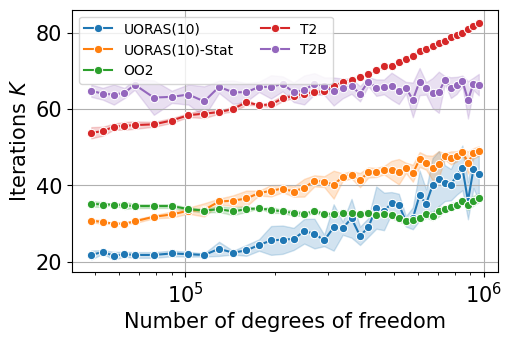

In [21]:
fig, axs = plt.subplots(1, 1, figsize=(5.5, 3.4))
ax = sns.lineplot(data=results, x='num_dofs', y='num_iters_tol_mean', 
                  hue="Method", hue_order=[r'UORAS(10)',
                                           r'UORAS(10)-Stat',
                                            'OO2', 'T2', 'T2B'], marker='o')
names = results['Method'].unique()
palette = sns.color_palette(n_colors=len(names))
for i, name in enumerate(names):
    subset = results[results['Method'] == name]
    
    plt.fill_between(
        subset['num_dofs'], 
        subset['num_iters_tol_mean'] - subset['num_iters_tol_sd'], 
        subset['num_iters_tol_mean'] + subset['num_iters_tol_sd'], 
        color=palette[i], 
        alpha=0.2
    )
plt.xscale('log')
plt.grid()
plt.legend(ncol=2, fontsize=10)
plt.xlabel("Number of degrees of freedom", fontsize=15)
plt.ylabel("Iterations $K$", fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.savefig('results_fig/iterations.pdf', bbox_inches='tight', pad_inches=0.01)